# 2023-03-13 Backscatter Drop Analysis

Like 2023-04-01, the March 13 cycle also shows a negative `d_empirical` mean (-0.46).
But the pattern is different:
- **April**: uniform drop across all 3 orbits (wet snow absorbing signal everywhere)
- **March**: orbit 93 dominates the drop (mean -0.86), orbit 71 moderate (-0.40),
  orbit 173 near zero (+0.06) — suggesting a more localized or orbit-specific cause

SNOTEL context: March 10-15 saw a major storm — SWE jumped from 18.5" to 22.6",
snow depth spiked from 68" to 91", and Tmax briefly hit +4.1 C on March 13 itself.

In [1]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pathlib import Path

RUNS_DIR = Path('/Users/zmhoppinen/Documents/sarvalanche/local/issw/high_danger_output/sarvalanche_runs')
SNOTEL_CSV = Path('/Users/zmhoppinen/Documents/sarvalanche/local/issw/snotels/490_STAND_WATERYEAR=2023.csv')

## 1. SNOTEL: Temperature, SWE, and Snow Depth

A large storm hit March 10-15 with simultaneous warming. The SWE jump (~4") and
snow depth spike (68" to 91") indicate heavy new snow loading, and Tmax briefly
exceeding 0 C means the surface may have been wet during parts of the SAR window.

In [2]:
# Parse SNOTEL
snotel = pd.read_csv(SNOTEL_CSV, skiprows=6, skipinitialspace=True)
snotel.columns = snotel.columns.str.strip()
snotel['Date'] = pd.to_datetime(snotel['Date'])

col_map = {}
for c in snotel.columns:
    if 'WTEQ' in c: col_map[c] = 'SWE_in'
    elif 'TMAX' in c: col_map[c] = 'Tmax_C'
    elif 'TMIN' in c: col_map[c] = 'Tmin_C'
    elif 'TAVG' in c: col_map[c] = 'Tavg_C'
    elif 'TOBS' in c: col_map[c] = 'Tobs_C'
    elif 'SNWD' in c: col_map[c] = 'SnowDepth_in'
    elif 'PREC' in c: col_map[c] = 'Precip_in'
snotel = snotel.rename(columns=col_map)
for c in ['Tmax_C', 'Tmin_C', 'Tavg_C', 'Tobs_C']:
    if c in snotel.columns:
        snotel[c] = snotel[c].replace(-99.9, np.nan)
snotel = snotel.set_index('Date')

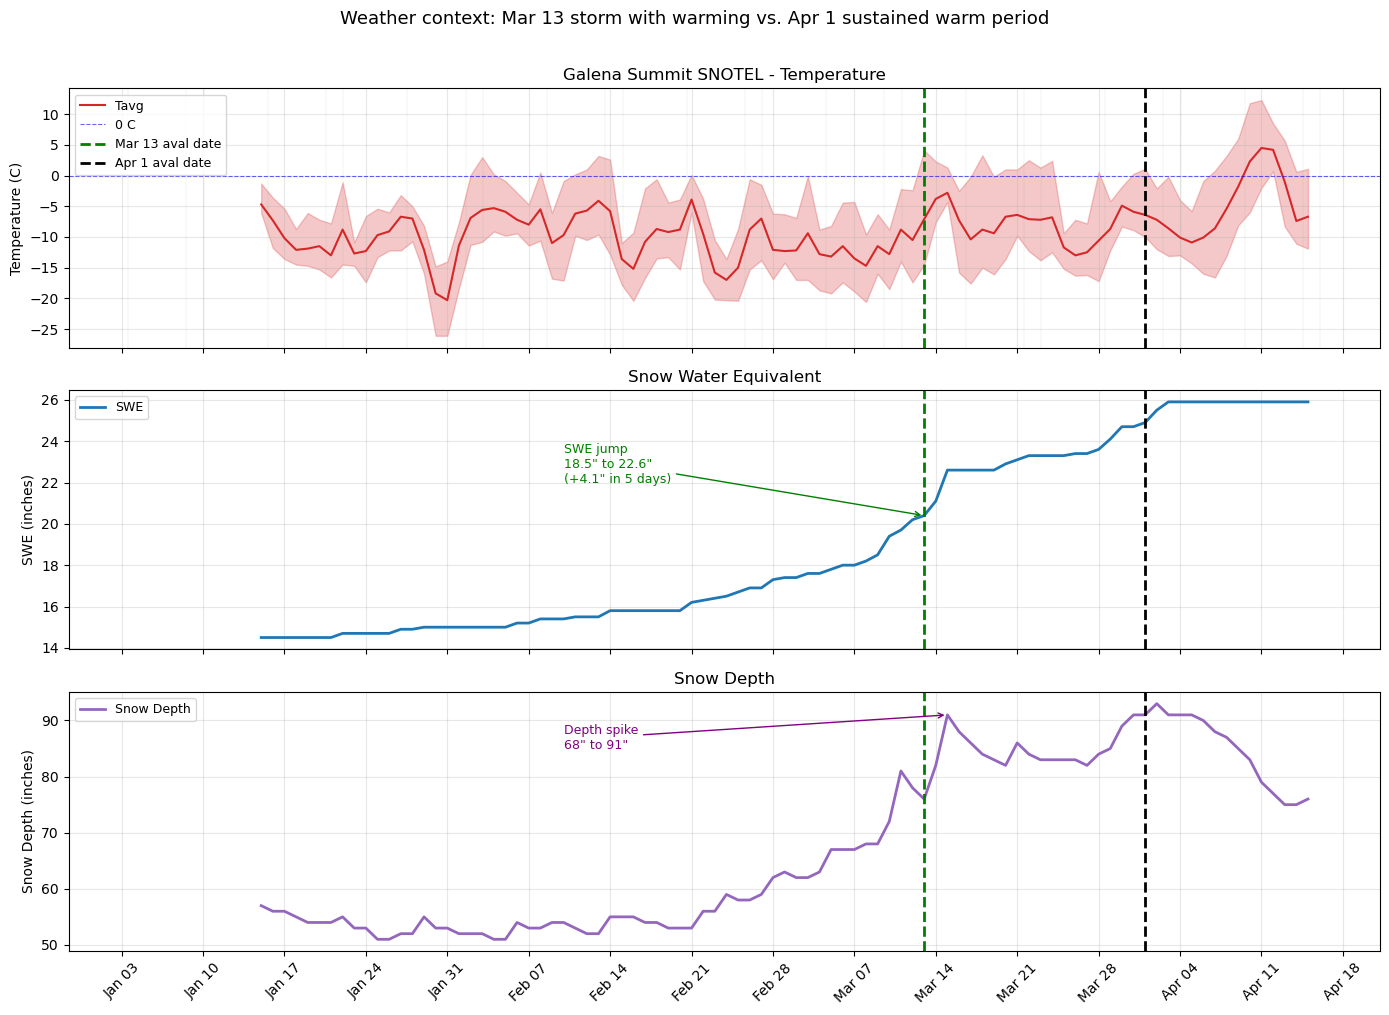

In [3]:
# Load SAR temporal weights for both dates
ds_mar = xr.open_dataset(RUNS_DIR / 'Banner_Summit_2023-03-13.nc')
sar_times_mar = pd.DatetimeIndex(ds_mar['w_temporal'].time.values)
ds_mar.close()

ds_apr = xr.open_dataset(RUNS_DIR / 'Banner_Summit_2023-04-01.nc')
sar_times_apr = pd.DatetimeIndex(ds_apr['w_temporal'].time.values)
ds_apr.close()

window = snotel.loc['2023-01-15':'2023-04-15']

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

mar_date = pd.Timestamp('2023-03-13')
apr_date = pd.Timestamp('2023-04-01')

# -- Temperature --
ax = axes[0]
ax.fill_between(window.index, window['Tmin_C'], window['Tmax_C'],
                alpha=0.25, color='tab:red')
ax.plot(window.index, window['Tavg_C'], 'tab:red', lw=1.5, label='Tavg')
ax.axhline(0, color='blue', ls='--', lw=0.8, alpha=0.6, label='0 C')
ax.axvline(mar_date, color='green', ls='--', lw=2, label='Mar 13 aval date')
ax.axvline(apr_date, color='black', ls='--', lw=2, label='Apr 1 aval date')
# Mark SAR acq dates for Mar 13 cycle
for t in sar_times_mar:
    ax.axvline(t, color='green', ls=':', lw=0.3, alpha=0.4)
ax.set_ylabel('Temperature (C)')
ax.set_title('Galena Summit SNOTEL - Temperature', fontsize=12)
ax.legend(loc='upper left', fontsize=9)
ax.grid(True, alpha=0.3)

# -- SWE --
ax = axes[1]
ax.plot(window.index, window['SWE_in'], 'tab:blue', lw=2, label='SWE')
ax.axvline(mar_date, color='green', ls='--', lw=2)
ax.axvline(apr_date, color='black', ls='--', lw=2)
# Annotate the big SWE jump
ax.annotate('SWE jump\n18.5" to 22.6"\n(+4.1" in 5 days)',
            xy=(pd.Timestamp('2023-03-13'), 20.4),
            xytext=(pd.Timestamp('2023-02-10'), 22),
            fontsize=9, arrowprops=dict(arrowstyle='->', color='green'),
            color='green')
ax.set_ylabel('SWE (inches)')
ax.set_title('Snow Water Equivalent', fontsize=12)
ax.legend(loc='upper left', fontsize=9)
ax.grid(True, alpha=0.3)

# -- Snow Depth --
ax = axes[2]
ax.plot(window.index, window['SnowDepth_in'], 'tab:purple', lw=2, label='Snow Depth')
ax.axvline(mar_date, color='green', ls='--', lw=2)
ax.axvline(apr_date, color='black', ls='--', lw=2)
ax.annotate('Depth spike\n68" to 91"',
            xy=(pd.Timestamp('2023-03-15'), 91),
            xytext=(pd.Timestamp('2023-02-10'), 85),
            fontsize=9, arrowprops=dict(arrowstyle='->', color='purple'),
            color='purple')
ax.set_ylabel('Snow Depth (inches)')
ax.set_title('Snow Depth', fontsize=12)
ax.legend(loc='upper left', fontsize=9)
ax.grid(True, alpha=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=1))
plt.xticks(rotation=45)

fig.suptitle('Weather context: Mar 13 storm with warming vs. Apr 1 sustained warm period',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## 2. SWE & Temperature Rate of Change

The daily SWE change and temperature trend around the two dates highlight the
difference: March 13 is a rapid loading event with a brief warm spike, April 1 is
a sustained warming with gradual SWE accumulation.

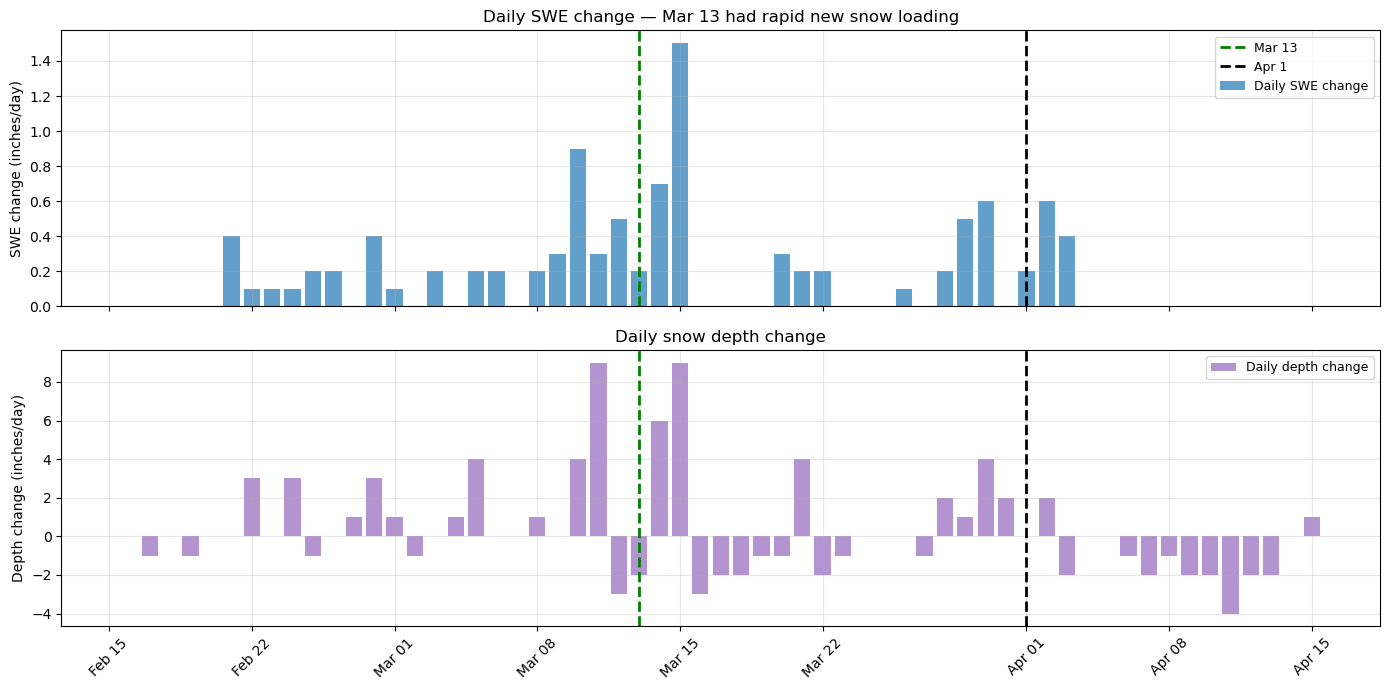

In [4]:
window = snotel.loc['2023-02-15':'2023-04-15'].copy()
window['dSWE'] = window['SWE_in'].diff()
window['dSnowDepth'] = window['SnowDepth_in'].diff()

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

ax = axes[0]
ax.bar(window.index, window['dSWE'], color='tab:blue', alpha=0.7, label='Daily SWE change')
ax.axvline(mar_date, color='green', ls='--', lw=2, label='Mar 13')
ax.axvline(apr_date, color='black', ls='--', lw=2, label='Apr 1')
ax.set_ylabel('SWE change (inches/day)')
ax.set_title('Daily SWE change — Mar 13 had rapid new snow loading', fontsize=12)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.bar(window.index, window['dSnowDepth'], color='tab:purple', alpha=0.7,
       label='Daily depth change')
ax.axvline(mar_date, color='green', ls='--', lw=2)
ax.axvline(apr_date, color='black', ls='--', lw=2)
ax.set_ylabel('Depth change (inches/day)')
ax.set_title('Daily snow depth change', fontsize=12)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## 3. Per-Orbit Empirical Distances: March vs. April vs. Winter

Key difference from April:
- **April 2023**: all 3 orbits drop uniformly (~-1.0 to -1.3) → scene-wide wet snow
- **March 2023**: orbit 93 drops hard (-0.86), orbit 71 moderate (-0.40),
  orbit 173 near zero (+0.06) → not a simple wet-snow explanation

Possible causes for orbit-dependent drop:
1. **New snow loading**: fresh dry snow increases volume scattering, but the effect
   depends on incidence angle (orbit geometry)
2. **Partial wet snow**: Tmax hit +4.1 C on Mar 13 — surface may have been wet during
   orbit 93 pass but frozen during orbit 173
3. **Wind redistribution**: storm winds can change surface roughness differently across
   look directions

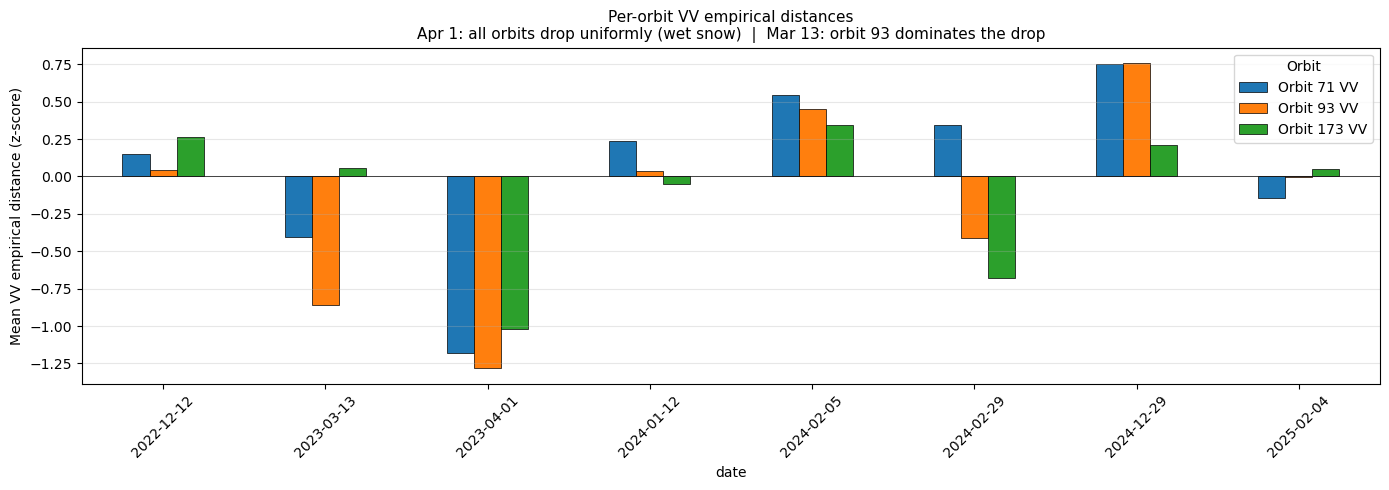

In [5]:
# Per-orbit empirical VV distances across all dates
nc_files = sorted(RUNS_DIR.glob('Banner_Summit_*.nc'))
orbit_vars = ['d_71_VV_empirical', 'd_93_VV_empirical', 'd_173_VV_empirical']
orbit_labels = ['Orbit 71 VV', 'Orbit 93 VV', 'Orbit 173 VV']

orbit_stats = []
for nc_path in nc_files:
    date_str = nc_path.stem.replace('Banner_Summit_', '')
    ds = xr.open_dataset(nc_path)
    row = {'date': date_str}
    for var, label in zip(orbit_vars, orbit_labels):
        if var in ds:
            vals = ds[var].values.ravel()
            vals = vals[~np.isnan(vals)]
            row[label] = vals.mean() if len(vals) > 0 else np.nan
        else:
            row[label] = np.nan
    orbit_stats.append(row)
    ds.close()

orbit_df = pd.DataFrame(orbit_stats).set_index('date')

fig, ax = plt.subplots(figsize=(14, 5))
orbit_df.plot(kind='bar', ax=ax, edgecolor='black', lw=0.5)
ax.axhline(0, color='black', ls='-', lw=0.5)
ax.set_ylabel('Mean VV empirical distance (z-score)')
ax.set_title(
    'Per-orbit VV empirical distances\n'
    'Apr 1: all orbits drop uniformly (wet snow)  |  Mar 13: orbit 93 dominates the drop',
    fontsize=11,
)
ax.tick_params(axis='x', rotation=45)
ax.grid(True, alpha=0.3, axis='y')
ax.legend(title='Orbit')
plt.tight_layout()
plt.show()

## 4. Empirical & Mahalanobis Histograms: March vs. April vs. Winter

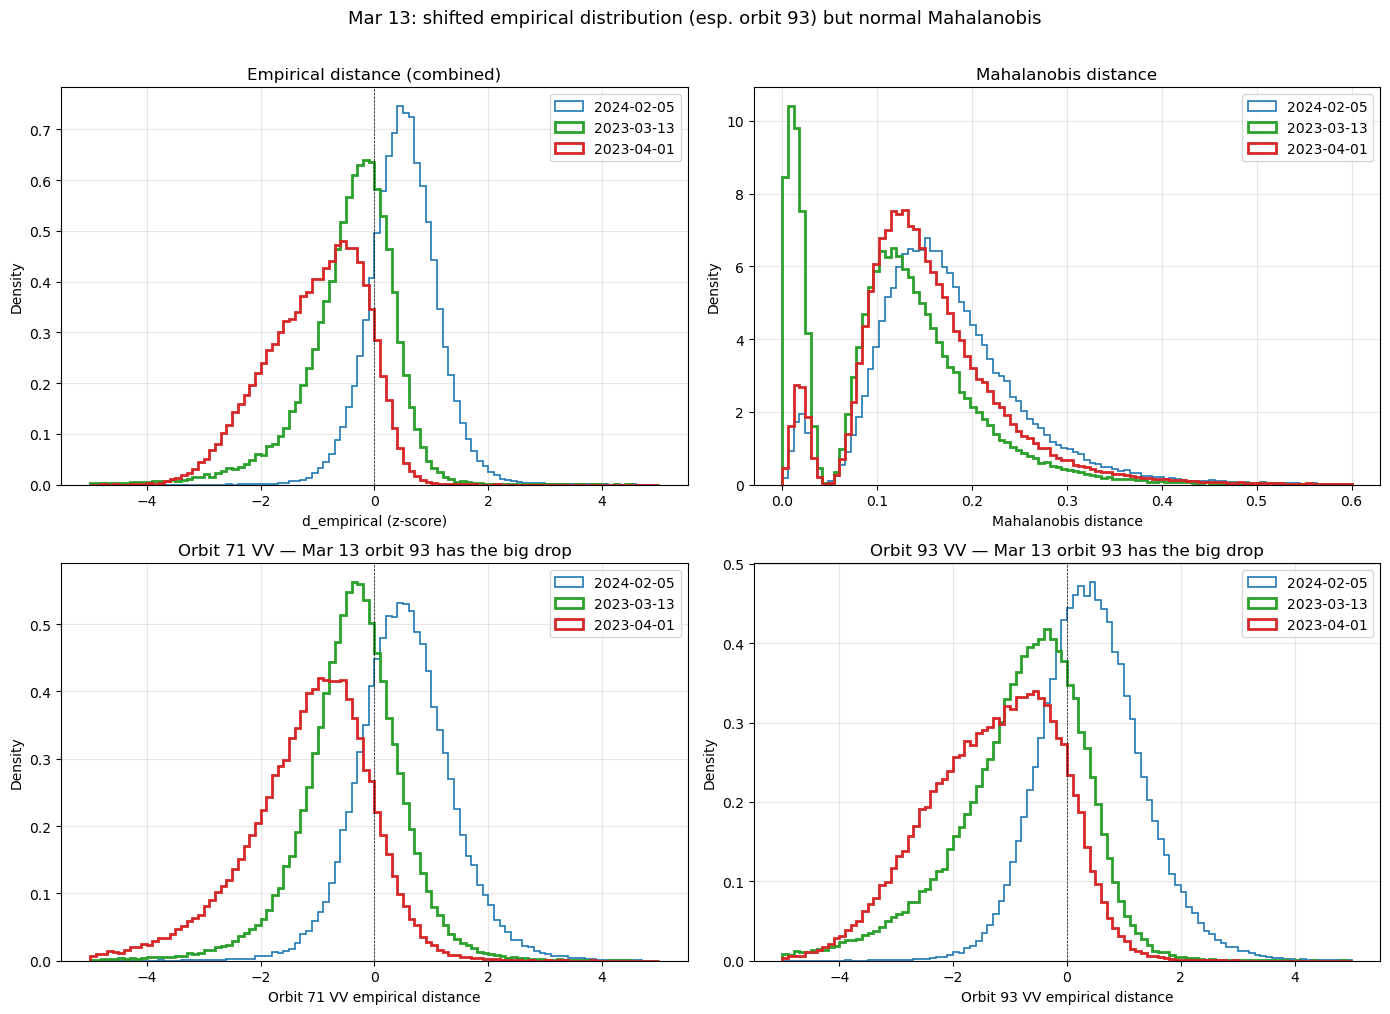

In [6]:
compare_dates = ['2024-02-05', '2023-03-13', '2023-04-01']
compare_colors = {'2024-02-05': 'tab:blue', '2023-03-13': 'tab:green', '2023-04-01': 'tab:red'}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

rng = np.random.default_rng(42)

# Top row: scene-wide d_empirical and Mahalanobis
for date_str in compare_dates:
    ds = xr.open_dataset(RUNS_DIR / f'Banner_Summit_{date_str}.nc')
    color = compare_colors[date_str]
    lw = 2.0 if date_str in ['2023-03-13', '2023-04-01'] else 1.2

    d_emp = ds['d_empirical'].values.ravel()
    d_emp = d_emp[~np.isnan(d_emp)]
    sample = rng.choice(d_emp, min(100_000, len(d_emp)), replace=False)
    axes[0, 0].hist(sample, bins=100, range=(-5, 5), density=True,
                    histtype='step', lw=lw, color=color, label=date_str)

    d_mah = ds['distance_mahalanobis'].values.ravel()
    d_mah = d_mah[~np.isnan(d_mah)]
    sample = rng.choice(d_mah, min(100_000, len(d_mah)), replace=False)
    axes[0, 1].hist(sample, bins=100, range=(0, 0.6), density=True,
                    histtype='step', lw=lw, color=color, label=date_str)
    ds.close()

axes[0, 0].axvline(0, color='black', ls='--', lw=0.5)
axes[0, 0].set_xlabel('d_empirical (z-score)')
axes[0, 0].set_ylabel('Density')
axes[0, 0].set_title('Empirical distance (combined)')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].set_xlabel('Mahalanobis distance')
axes[0, 1].set_ylabel('Density')
axes[0, 1].set_title('Mahalanobis distance')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Bottom row: per-orbit VV empirical for Mar 13 vs winter
for oi, (var, olabel) in enumerate(zip(orbit_vars[:2], orbit_labels[:2])):
    ax = axes[1, oi]
    for date_str in compare_dates:
        ds = xr.open_dataset(RUNS_DIR / f'Banner_Summit_{date_str}.nc')
        color = compare_colors[date_str]
        lw = 2.0 if date_str in ['2023-03-13', '2023-04-01'] else 1.2
        if var in ds:
            vals = ds[var].values.ravel()
            vals = vals[~np.isnan(vals)]
            if len(vals) > 0:
                sample = rng.choice(vals, min(100_000, len(vals)), replace=False)
                ax.hist(sample, bins=100, range=(-5, 5), density=True,
                        histtype='step', lw=lw, color=color, label=date_str)
        ds.close()
    ax.axvline(0, color='black', ls='--', lw=0.5)
    ax.set_xlabel(f'{olabel} empirical distance')
    ax.set_ylabel('Density')
    ax.set_title(f'{olabel} — Mar 13 orbit 93 has the big drop')
    ax.legend()
    ax.grid(True, alpha=0.3)

fig.suptitle(
    'Mar 13: shifted empirical distribution (esp. orbit 93) but normal Mahalanobis',
    fontsize=13, y=1.01,
)
plt.tight_layout()
plt.show()

## 5. ML Distances: Does Mahalanobis Also See Orbit 93 as Anomalous?

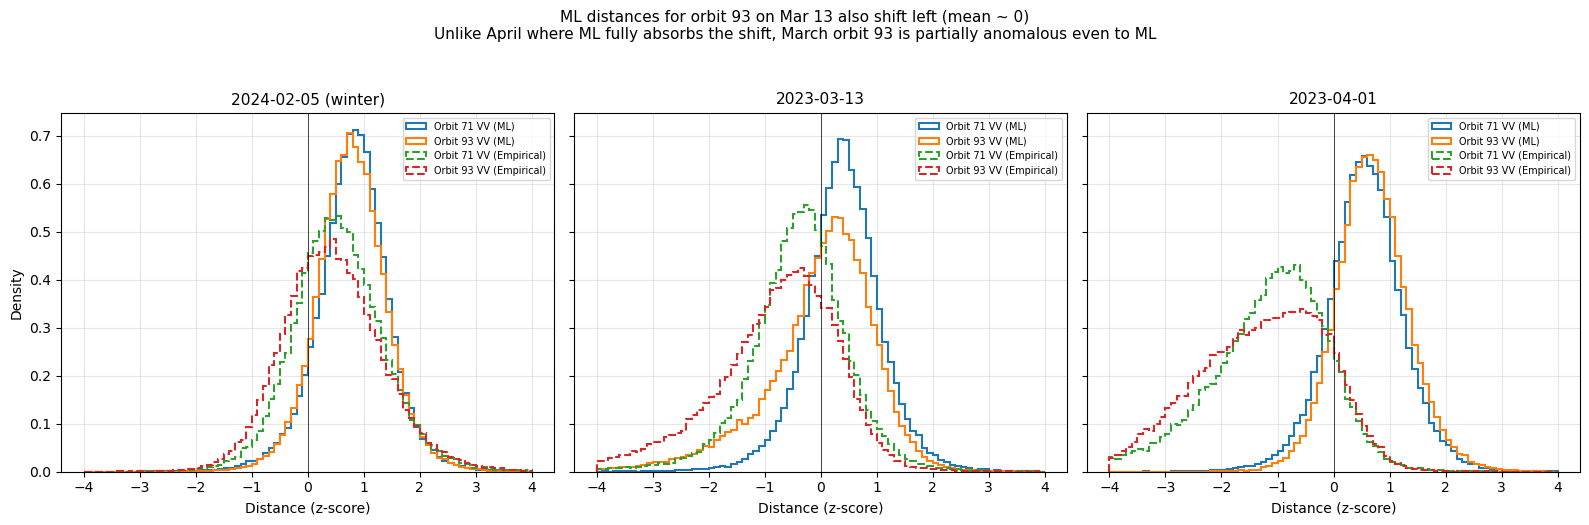

In [7]:
# Compare ML (Mahalanobis component) distances per orbit for Mar 13 vs winter
ml_vars = ['d_71_VV_ml', 'd_93_VV_ml', 'd_71_VV_empirical', 'd_93_VV_empirical']
ml_labels = ['Orbit 71 VV (ML)', 'Orbit 93 VV (ML)',
             'Orbit 71 VV (Empirical)', 'Orbit 93 VV (Empirical)']

compare = {
    '2024-02-05 (winter)': RUNS_DIR / 'Banner_Summit_2024-02-05.nc',
    '2023-03-13': RUNS_DIR / 'Banner_Summit_2023-03-13.nc',
    '2023-04-01': RUNS_DIR / 'Banner_Summit_2023-04-01.nc',
}

fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)

for ax, (title, nc_path) in zip(axes, compare.items()):
    ds = xr.open_dataset(nc_path)
    for var, label in zip(ml_vars, ml_labels):
        if var in ds:
            vals = ds[var].values.ravel()
            vals = vals[~np.isnan(vals)]
            if len(vals) > 0:
                sample = rng.choice(vals, min(50_000, len(vals)), replace=False)
                ls = '-' if 'ml' in var else '--'
                ax.hist(sample, bins=80, range=(-4, 4), density=True,
                        histtype='step', lw=1.5, ls=ls, label=label)
    ax.axvline(0, color='black', ls='-', lw=0.5)
    ax.set_xlabel('Distance (z-score)')
    ax.set_title(title, fontsize=11)
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)
    ds.close()

axes[0].set_ylabel('Density')
fig.suptitle(
    'ML distances for orbit 93 on Mar 13 also shift left (mean ~ 0)\n'
    'Unlike April where ML fully absorbs the shift, March orbit 93 is partially anomalous even to ML',
    fontsize=11, y=1.04,
)
plt.tight_layout()
plt.show()

## 6. Summary: Two Different Mechanisms

| | 2023-03-13 | 2023-04-01 |
|---|---|---|
| **d_empirical mean** | -0.46 | -1.04 |
| **Orbit pattern** | Orbit 93 dominates drop (-0.86), others moderate | All 3 orbits drop uniformly (-1.0 to -1.3) |
| **ML orbit 93** | Also anomalous (mean ~0, vs 0.4-0.7 typical) | Normal (~0.5-0.7) |
| **SNOTEL** | Major storm: +4" SWE in 5 days, Tmax briefly +4.1 C | Sustained warming, Tmax ~+1 C |
| **Snow depth** | Spike 68" to 91" (new snow loading) | Stable ~91" |
| **Likely cause** | Storm-driven: fresh snow loading + brief surface melt, orbit-dependent | Wet snow: scene-wide liquid water in snowpack |

**March 13** looks like a **storm cycle**: heavy new snow caused backscatter changes
(volume scattering from fresh snow + possible brief surface wetting during Tmax spike).
The orbit-dependent pattern suggests the backscatter change depends on incidence angle
or acquisition timing relative to the warm period.

The ML model partially handles March (orbit 71 looks normal in ML space) but orbit 93
is still anomalous even to ML — the storm created real backscatter changes that aren't
just wet-snow absorption.

**April 1** is a cleaner **wet-snow case**: uniform drop, ML fully absorbs it.